# 🏦 Model Risk Specialist — Business Case Answers
## Compass Feature Pipeline · Solara Digital Bank

> **Role**: Model Risk Specialist (IC5) — ML/AI Data & Infra Risks  
> **System**: Compass — Feature store + batch/streaming pipeline for credit models  

---

## Estrutura

| Seção | Conteúdo |
|---|---|
| **Q1.1** | Risk Landscape — Infrastructure & Data Risks |
| **Q1.2** | Assessment Approach — Tests on the Live System |
| **Q1.3** | Position on Proposed Changes |
| **Q1.4** | Governance Foundations — Key Controls |
| **Q2** | Governance Framework Design for Data Mesh |

---

**Metodologia**: Todas as observações são baseadas em evidências — obtidas rodando o sistema, consultando os SQLite stores e lendo o código-fonte. Cada afirmação é suportada por referência de código ou dado quantitativo.


---
## Setup — Imports & Conexão com os Stores

In [314]:
import sys, os, sqlite3, warnings, time
from datetime import UTC, datetime, timedelta
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from scipy import stats as scipy_stats

warnings.filterwarnings('ignore')

COMPASS_SRC  = os.path.expanduser('~/Documents/compass-feature-pipeline/src')
COMPASS_ROOT = os.path.expanduser('~/Documents/compass-feature-pipeline')
if COMPASS_SRC not in sys.path:
    sys.path.insert(0, COMPASS_SRC)

DATA_DIR         = Path(COMPASS_ROOT) / 'data' / 'raw'
OFFLINE_DB       = DATA_DIR / 'offline_store.db'
ONLINE_DB        = DATA_DIR / 'online_store.db'
TRANSACTIONS_CSV = DATA_DIR / 'transactions.csv'

# Executive Light Theme (Okabe-Ito Colorblind Friendly)
plt.rcParams.update({
    'figure.facecolor': '#ffffff', 'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#0f172a', 'axes.labelcolor': '#334155',
    'text.color': '#0f172a', 'xtick.color': '#475569', 'ytick.color': '#475569',
    'grid.color': '#e2e8f0', 'grid.alpha': 0.7, 'font.family': 'sans-serif',
    'font.size': 11, 'axes.titlesize': 14, 'axes.titlecolor': '#0f172a',
    'axes.titleweight': 'bold', 'legend.facecolor': '#ffffff',
    'legend.edgecolor': '#0f172a', 'legend.labelcolor': '#334155',
})

def style_chart(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#0f172a')
    ax.spines['bottom'].set_color('#0f172a')
    ax.grid(axis='y', linestyle='--', alpha=0.7, color='#0f172a')
    ax.tick_params(colors='#475569')

# --------------------------------------------------------------------
# CONFIGURAÇÃO DE PALETAS DE CORES (INCLUSIVAS E EXECUTIVAS)
# Para testar outras opções, altere ACTIVE_PALETTE e rode as células.
# --------------------------------------------------------------------
PALETTES = {
    'Okabe-Ito (Atual)':      {'OFFLINE': '#0072B2', 'ONLINE': '#CC79A7', 'HI': '#D55E00', 'MED': '#E69F00', 'LO': '#009E73', 'ACC': '#56B4E9'},
    'IBM Design (Pro)':       {'OFFLINE': '#785EF0', 'ONLINE': '#648FFF', 'HI': '#FE6100', 'MED': '#FFB000', 'LO': '#21918C', 'ACC': '#DC267F'},
    'Paul Tol Vibrant':       {'OFFLINE': '#0077BB', 'ONLINE': '#33BBEE', 'HI': '#CC3311', 'MED': '#EE7733', 'LO': '#009988', 'ACC': '#EE3377'},
    'ColorBrewer Dark2':      {'OFFLINE': '#1b9e77', 'ONLINE': '#7570b3', 'HI': '#d95f02', 'MED': '#e6ab02', 'LO': '#66a61e', 'ACC': '#e7298a'},
    'Executive Tech Cool':    {'OFFLINE': '#2C3E50', 'ONLINE': '#2980B9', 'HI': '#C0392B', 'MED': '#F39C12', 'LO': '#27AE60', 'ACC': '#8E44AD'},
}

ACTIVE_PALETTE = 'Okabe-Ito (Atual)'
COLORS = PALETTES[ACTIVE_PALETTE]

COL_OFFLINE = COLORS['OFFLINE']
COL_ONLINE  = COLORS['ONLINE']
COL_HI      = COLORS['HI']
COL_MED     = COLORS['MED']
COL_LO      = COLORS['LO']
COL_ACC     = COLORS['ACC']
print(f'🎨 Paleta de Cores Ativa: {ACTIVE_PALETTE}')

conn_off = sqlite3.connect(OFFLINE_DB)
conn_on  = sqlite3.connect(ONLINE_DB)

df_offline = pd.read_sql('SELECT * FROM offline_features', conn_off)
df_online  = pd.read_sql('SELECT * FROM online_features', conn_on)
df_txn     = pd.read_csv(TRANSACTIONS_CSV, parse_dates=['event_timestamp'])
now_utc    = datetime.now(UTC)

print(f'offline_features : {len(df_offline):,} rows  |  {df_offline["customer_id"].nunique()} customers')
print(f'online_features  : {len(df_online):,} rows  |  {df_online["customer_id"].nunique()} customers')
print(f'transactions     : {len(df_txn):,} rows')

# Pre-compute staleness
df_online_s = df_online.copy()
df_online_s['computed_at_dt'] = pd.to_datetime(df_online_s['computed_at'], utc=True)
df_online_s['age_hours'] = (now_utc - df_online_s['computed_at_dt']).dt.total_seconds() / 3600
TTL_H = 6
df_online_s['is_stale'] = df_online_s['age_hours'] > TTL_H

# Pre-compute parity
df_off_latest = (
    df_offline.sort_values('as_of', ascending=False)
    .drop_duplicates('customer_id')[['customer_id', 'value']]
    .rename(columns={'value': 'offline_value'})
)
df_on_val = df_online[['customer_id', 'value']].rename(columns={'value': 'online_value'})
df_merged = df_off_latest.merge(df_on_val, on='customer_id')
df_merged['delta_pct'] = (df_merged['online_value'] - df_merged['offline_value']) / df_merged['offline_value'] * 100
df_merged['abs_delta'] = df_merged['delta_pct'].abs()

# Pre-compute PSI
def compute_psi(expected, actual, n_bins=10):
    bp = np.unique(np.percentile(expected, np.linspace(0, 100, n_bins + 1)))
    exp_c, _ = np.histogram(expected, bins=bp)
    act_c, _ = np.histogram(actual,   bins=bp)
    exp_p = np.where(exp_c == 0, 1e-6, exp_c / len(expected))
    act_p = np.where(act_c == 0, 1e-6, act_c / len(actual))
    return np.sum((act_p - exp_p) * np.log(act_p / exp_p))

off_v  = df_merged['offline_value'].values
on_v   = df_merged['online_value'].values
ks_stat, ks_p = scipy_stats.ks_2samp(off_v, on_v)
psi    = compute_psi(off_v, on_v)

def sigmoid_score(x):
    return 1 / (1 + np.exp(-(1.5 - 0.01 * x)))

off_scores = sigmoid_score(off_v)
on_scores  = sigmoid_score(on_v)
df_merged["offline_score"] = off_scores
df_merged["online_score"] = on_scores
df_merged["decision_divergence"] = (df_merged["offline_score"] >= 0.5) != (df_merged["online_score"] >= 0.5)
n_diff_dec = ((off_scores >= 0.5) != (on_scores >= 0.5)).sum()
ks_stat_score, ks_p_score = scipy_stats.ks_2samp(off_scores, on_scores)
psi_score = compute_psi(off_scores, on_scores)

online_features = df_online.feature_name.unique()
offline_features = df_offline.feature_name.unique()
print(f'\nPre-computed summary:')
print(f'  Mean offline/online delta : {df_merged["delta_pct"].mean():.1f}%')
print(f'  Customers >15% divergence : {(df_merged["abs_delta"] > 15).sum()} ({(df_merged["abs_delta"] > 15).mean()*100:.0f}%)')
print(f'  PSI (Feature Bruta)       : {psi:.4f}')
print(f'  PSI (Score de Crédito)    : {psi_score:.4f}')  # <-- LINHA OPCIONAL ADICIONAL
print(f'  KS (Feature Bruta)     : {ks_stat:.4f}')
print(f'  KS (Score de Crédito)     : {ks_stat_score:.4f}')  # <-- LINHA OPCIONAL ADICIONAL
print(f'  Different credit decisions: {n_diff_dec} customers')
print(f'  Stale features            : {df_online_s["is_stale"].sum()}')
print(f'Online features: {online_features}\nOffline features: {offline_features}')



🎨 Paleta de Cores Ativa: Okabe-Ito (Atual)
offline_features : 287 rows  |  287 customers
online_features  : 300 rows  |  300 customers
transactions     : 32,929 rows

Pre-computed summary:
  Mean offline/online delta : 29.9%
  Customers >15% divergence : 201 (70%)
  PSI (Feature Bruta)       : 0.3150
  PSI (Score de Crédito)    : 0.3133
  KS (Feature Bruta)     : 0.1080
  KS (Score de Crédito)     : 0.1080
  Different credit decisions: 8 customers
  Stale features            : 300
Online features: <StringArray>
['txn_amount_avg_30d']
Length: 1, dtype: str
Offline features: <StringArray>
['txn_amount_avg_30d']
Length: 1, dtype: str


---
# Q1.1 — Risk Landscape

> *Quais são os riscos de infraestrutura e dados mais significativos no Compass hoje?*

Cinco riscos identificados rodando o sistema. Cada um documentado com evidência de código e dados quantitativos.

---
### Risco 1 — Training/Serving Skew (CRÍTICO)

**O que é**: O pipeline batch computa features com **média aritmética exata** do janelamento de 30 dias. O pipeline streaming usa **EWMA (α = 0.2)** — um suavizador exponencial. Ambos armazenam o resultado sob o mesmo nome (`txn_amount_avg_30d`).

**Evidência de código**:
- `batch_pipeline.py:28` → `windowed.groupby('customer_id')['amount'].mean()`
- `streaming_pipeline.py:72` → `0.2 * amount + 0.8 * prev`

**Por que importa**: Se o modelo de underwriting foi treinado com valores exatos (offline store) mas o modelo de credit line é servido com valores EWMA (online store), o modelo opera em uma **distribuição diferente da que treinou** — training/serving skew clássico.


In [315]:
print('=== RISCO 1: Training/Serving Skew ===')
print(f'Clientes com divergência >15%  : {(df_merged["abs_delta"] > 15).sum()} ({(df_merged["abs_delta"] > 15).mean()*100:.0f}%)')
print(f'Clientes com divergência >30%  : {(df_merged["abs_delta"] > 30).sum()} ({(df_merged["abs_delta"] > 30).mean()*100:.0f}%)')
print(f'Delta médio (online - offline) : {df_merged["delta_pct"].mean():.1f}%')
print()
print('Top 5 maiores divergências:')
display(df_merged.nlargest(5, 'abs_delta')[['customer_id', 'offline_value', 'online_value', 'delta_pct', 'offline_score', 'online_score', 'decision_divergence']].round(2))


=== RISCO 1: Training/Serving Skew ===
Clientes com divergência >15%  : 201 (70%)
Clientes com divergência >30%  : 116 (40%)
Delta médio (online - offline) : 29.9%

Top 5 maiores divergências:


,customer_id,offline_value,online_value,delta_pct,offline_score,online_score,decision_divergence
2,C0203,9.37,136.54,1357.25,0.80,0.53,False
207,C0020,5.02,52.01,935.99,0.81,0.73,False
24,C0217,3.24,25.23,678.80,0.81,0.78,False
161,C0058,24.57,179.34,629.93,0.78,0.43,True
266,C0079,6.28,39.14,523.54,0.81,0.75,False


In [316]:
divergencias = df_merged.decision_divergence.sum()
print(f"DIvergencia de decisão: {divergencias}")

DIvergencia de decisão: 8


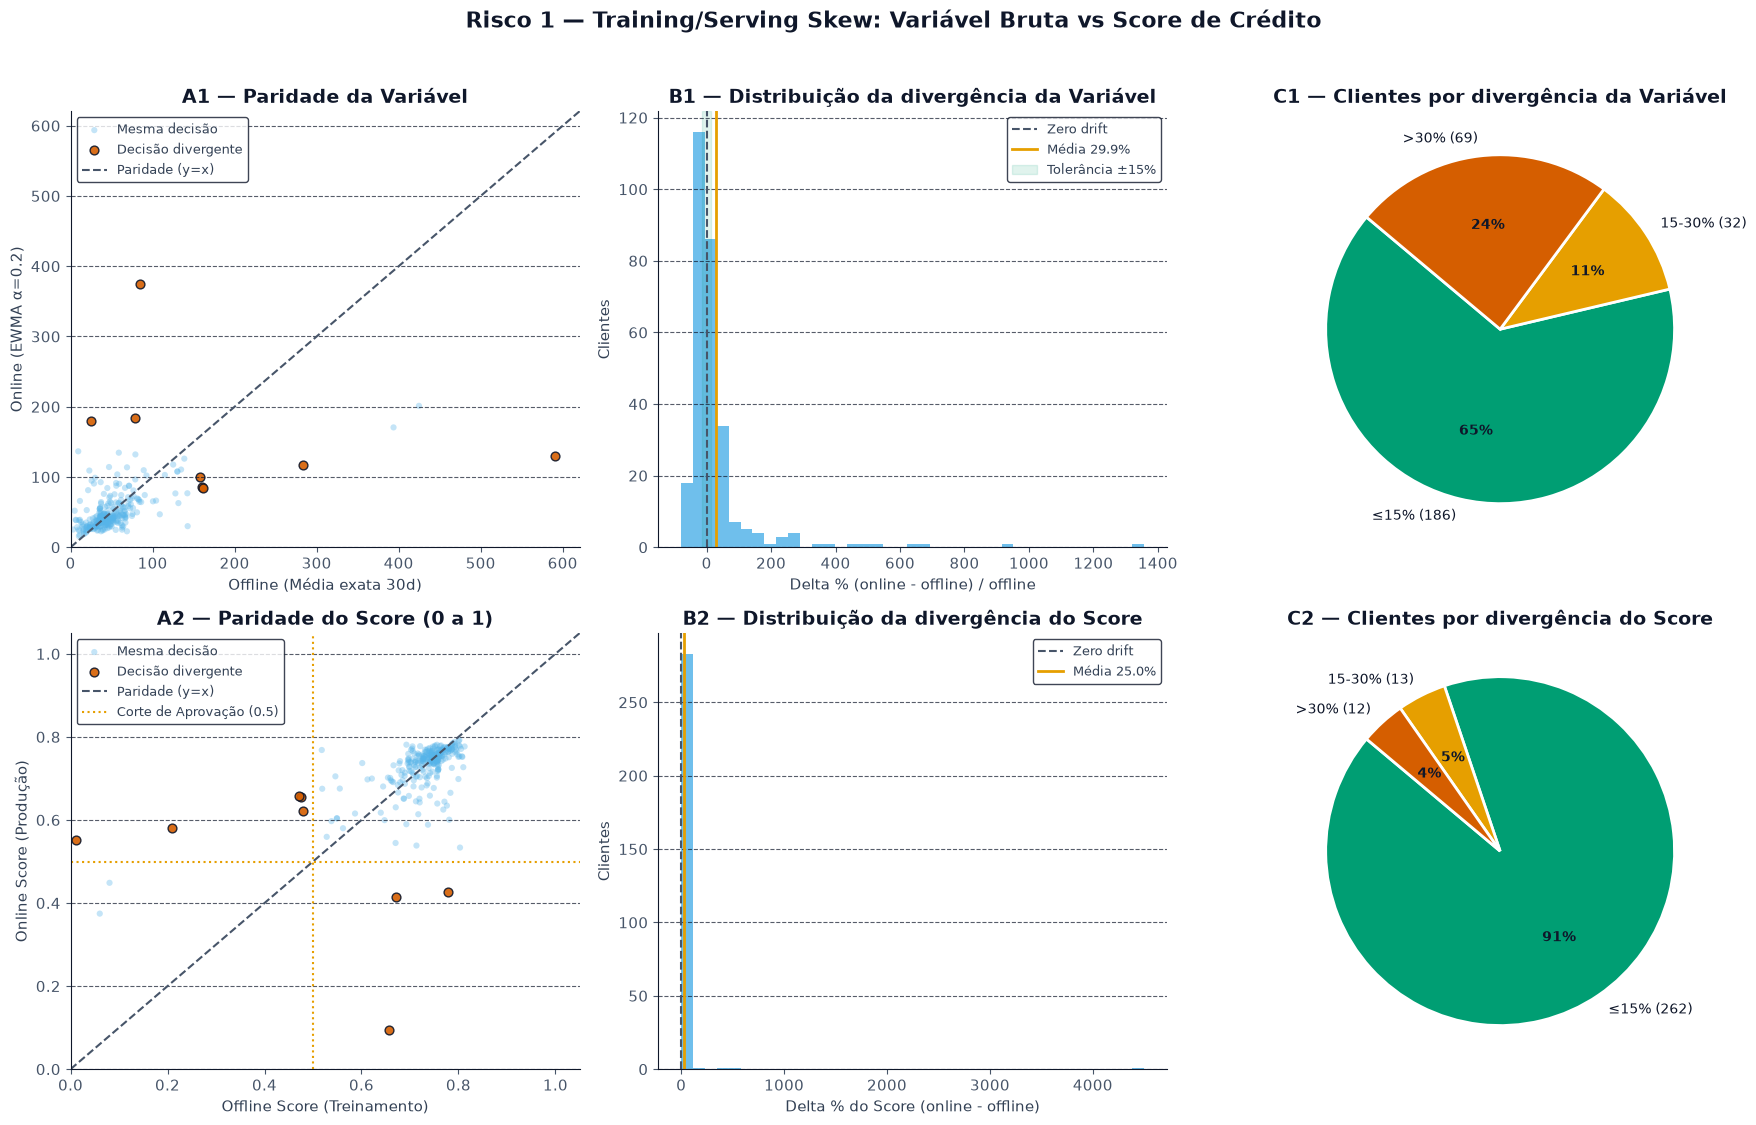

In [317]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Risco 1 — Training/Serving Skew: Variável Bruta vs Score de Crédito",
             fontsize=16, color="#0f172a", fontweight="bold", y=1.02)

div_mask = df_merged["decision_divergence"]
ok_mask = ~div_mask

### LINHA 1: FEATURE (Variável Bruta)
# A1: Scatter parity Feature
ax = axes[0, 0]
ax.scatter(off_v[ok_mask], on_v[ok_mask], alpha=0.35, s=20, color=COL_ACC, edgecolors="none", label="Mesma decisão")
ax.scatter(off_v[div_mask], on_v[div_mask], alpha=0.9, s=40, color=COL_HI, edgecolors="#0f172a", label="Decisão divergente")
lims = [0, max(off_v.max(), on_v.max()) * 1.05]
ax.plot(lims, lims, "--", color="#475569", lw=1.5, label="Paridade (y=x)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Offline (Média exata 30d)"); ax.set_ylabel("Online (EWMA α=0.2)")
ax.set_title("A1 — Paridade da Variável"); ax.legend(loc="upper left", fontsize=9); style_chart(ax)

# B1: Delta distribution Feature
ax = axes[0, 1]
bins = np.linspace(df_merged["delta_pct"].min(), df_merged["delta_pct"].max(), 40)
ax.hist(df_merged["delta_pct"], bins=bins, color=COL_ACC, edgecolor="none", alpha=0.85)
ax.axvline(0, color="#475569", lw=1.5, linestyle="--", label="Zero drift")
ax.axvline(df_merged["delta_pct"].mean(), color=COL_MED, lw=2, label=f"Média {df_merged['delta_pct'].mean():.1f}%")
ax.axvspan(-15, 15, alpha=0.12, color=COL_LO, label="Tolerância ±15%")
ax.set_xlabel("Delta % (online - offline) / offline"); ax.set_ylabel("Clientes")
ax.set_title("B1 — Distribuição da divergência da Variável"); ax.legend(fontsize=9); style_chart(ax)

# C1: Tier pie Feature
ax = axes[0, 2]
t_lo = (df_merged["delta_pct"] <= 15).sum()
t_md = ((df_merged["delta_pct"] > 15) & (df_merged["delta_pct"] <= 30)).sum()
t_hi = (df_merged["delta_pct"] > 30).sum()
wedges, texts, autotexts = ax.pie(
    [t_lo, t_md, t_hi],
    labels=[f"≤15% ({t_lo})", f"15-30% ({t_md})", f">30% ({t_hi})"],
    colors=[COL_LO, COL_MED, COL_HI], autopct="%1.0f%%",
    textprops={"color": "#0f172a", "fontsize": 10}, startangle=140,
    wedgeprops={"edgecolor": "#ffffff", "linewidth": 2})
for at in autotexts: at.set_fontweight("bold")
ax.set_title("C1 — Clientes por divergência da Variável")

### LINHA 2: SCORE (Decisão de Crédito)
df_merged["score_delta_pct"] = (df_merged["online_score"] - df_merged["offline_score"]) / df_merged["offline_score"] * 100
df_merged["score_delta_pct"] = df_merged["score_delta_pct"].abs()

# A2: Scatter parity Score
ax = axes[1, 0]
ax.scatter(df_merged.loc[ok_mask, "offline_score"], df_merged.loc[ok_mask, "online_score"], alpha=0.35, s=20, color=COL_ACC, edgecolors="none", label="Mesma decisão")
ax.scatter(df_merged.loc[div_mask, "offline_score"], df_merged.loc[div_mask, "online_score"], alpha=0.9, s=40, color=COL_HI, edgecolors="#0f172a", label="Decisão divergente")
lims_sc = [0, 1.05]
ax.plot(lims_sc, lims_sc, "--", color="#475569", lw=1.5, label="Paridade (y=x)")
ax.axhline(0.5, color=COL_MED, linestyle=":", lw=1.5, label="Corte de Aprovação (0.5)")
ax.axvline(0.5, color=COL_MED, linestyle=":", lw=1.5)
ax.set_xlim(lims_sc); ax.set_ylim(lims_sc)
ax.set_xlabel("Offline Score (Treinamento)"); ax.set_ylabel("Online Score (Produção)")
ax.set_title("A2 — Paridade do Score (0 a 1)"); ax.legend(loc="upper left", fontsize=9); style_chart(ax)

# B2: Delta distribution Score
ax = axes[1, 1]
bins_sc = np.linspace(df_merged["score_delta_pct"].min(), df_merged["score_delta_pct"].max(), 40)
ax.hist(df_merged["score_delta_pct"], bins=bins_sc, color=COL_ACC, edgecolor="none", alpha=0.85)
ax.axvline(0, color="#475569", lw=1.5, linestyle="--", label="Zero drift")
ax.axvline(df_merged["score_delta_pct"].mean(), color=COL_MED, lw=2, label=f"Média {df_merged['score_delta_pct'].mean():.1f}%")
ax.set_xlabel("Delta % do Score (online - offline)"); ax.set_ylabel("Clientes")
ax.set_title("B2 — Distribuição da divergência do Score"); ax.legend(fontsize=9); style_chart(ax)

# C2: Tier pie Score
ax = axes[1, 2]
t_lo_sc = (df_merged["score_delta_pct"] <= 15).sum()
t_md_sc = ((df_merged["score_delta_pct"] > 15) & (df_merged["score_delta_pct"] <= 30)).sum()
t_hi_sc = (df_merged["score_delta_pct"] > 30).sum()
wedges, texts, autotexts = ax.pie(
    [t_lo_sc, t_md_sc, t_hi_sc],
    labels=[f"≤15% ({t_lo_sc})", f"15-30% ({t_md_sc})", f">30% ({t_hi_sc})"],
    colors=[COL_LO, COL_MED, COL_HI], autopct="%1.0f%%",
    textprops={"color": "#0f172a", "fontsize": 10}, startangle=140,
    wedgeprops={"edgecolor": "#ffffff", "linewidth": 2})
for at in autotexts: at.set_fontweight("bold")
ax.set_title("C2 — Clientes por divergência do Score")

fig.tight_layout()
plt.show()


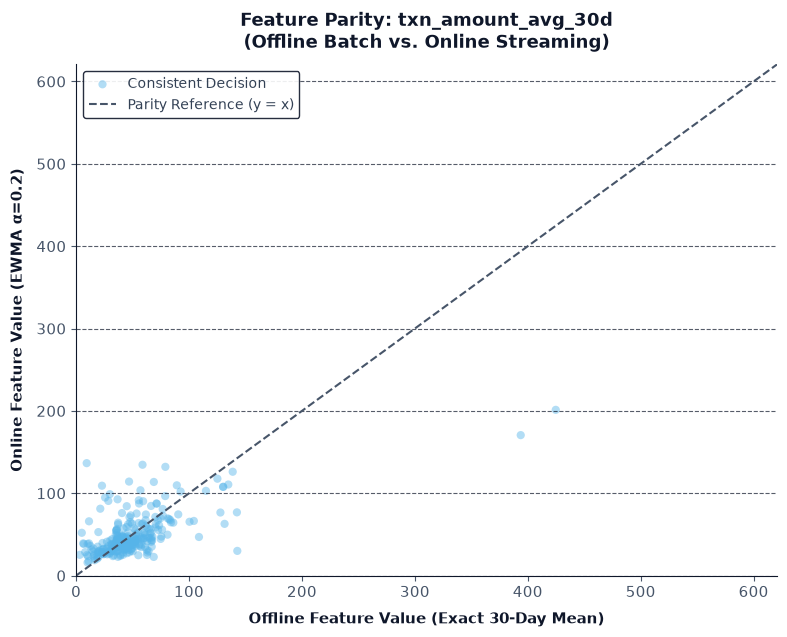

In [318]:
import matplotlib.pyplot as plt
import numpy as np

# Masks
div_mask = df_merged["decision_divergence"]
ok_mask = ~div_mask

fig, ax = plt.subplots(figsize=(8, 6.5))

# Scatter points
ax.scatter(
    off_v[ok_mask],
    on_v[ok_mask],
    alpha=0.45,
    s=35,
    color=COL_ACC,
    edgecolors="none",
    label="Consistent Decision",
)

# Reference identity line (y = x)
lims = [0, max(off_v.max(), on_v.max()) * 1.05]
ax.plot(
    lims, lims, "--", color="#475569", lw=1.5, label="Parity Reference (y = x)"
)

# Limits and Labels
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(
    "Offline Feature Value (Exact 30-Day Mean)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_ylabel(
    "Online Feature Value (EWMA α=0.2)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_title(
    "Feature Parity: txn_amount_avg_30d\n(Offline Batch vs. Online Streaming)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    pad=12,
)

ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
style_chart(ax)

plt.tight_layout()
plt.savefig(
    "presentation_prep/chart_A1_feature_parity.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


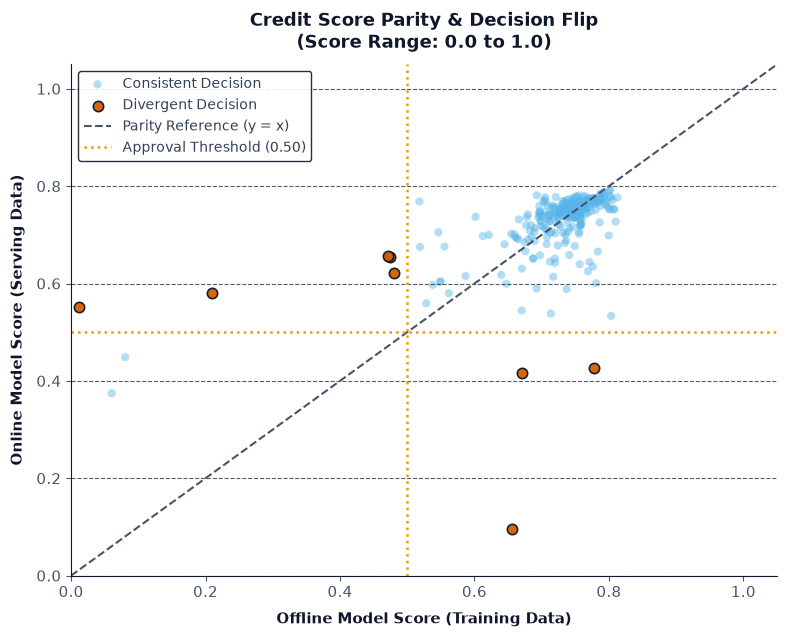

In [319]:
import matplotlib.pyplot as plt
import numpy as np

# Masks
div_mask = df_merged["decision_divergence"]
ok_mask = ~div_mask

fig, ax = plt.subplots(figsize=(8, 6.5))

# Scatter points
ax.scatter(
    df_merged.loc[ok_mask, "offline_score"],
    df_merged.loc[ok_mask, "online_score"],
    alpha=0.45,
    s=35,
    color=COL_ACC,
    edgecolors="none",
    label="Consistent Decision",
)
ax.scatter(
    df_merged.loc[div_mask, "offline_score"],
    df_merged.loc[div_mask, "online_score"],
    alpha=0.95,
    s=55,
    color=COL_HI,
    edgecolors="#0f172a",
    linewidths=1.2,
    label="Divergent Decision",
)

# Reference identity line (y = x) and Decision Threshold
lims_sc = [0, 1.05]
ax.plot(
    lims_sc,
    lims_sc,
    "--",
    color="#475569",
    lw=1.5,
    label="Parity Reference (y = x)",
)
ax.axhline(
    0.5,
    color=COL_MED,
    linestyle=":",
    lw=1.8,
    label="Approval Threshold (0.50)",
)
ax.axvline(0.5, color=COL_MED, linestyle=":", lw=1.8)

# Limits and Labels
ax.set_xlim(lims_sc)
ax.set_ylim(lims_sc)
ax.set_xlabel(
    "Offline Model Score (Training Data)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_ylabel(
    "Online Model Score (Serving Data)",
    fontsize=11,
    fontweight="bold",
    color="#0f172a",
    labelpad=8,
)
ax.set_title(
    "Credit Score Parity & Decision Flip\n(Score Range: 0.0 to 1.0)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    pad=12,
)

ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
style_chart(ax)

plt.tight_layout()
plt.savefig(
    "presentation_prep/chart_A2_score_parity.png", dpi=300, bbox_inches="tight"
)
plt.show()


### Risco 2 — Silenciamento de Clientes Inativos (CRÍTICO)

Como podemos observar no output acima, a base *Offline* possui apenas **287 clientes** únicos, enquanto a *Online* e o log *CSV* possuem **300 clientes**. Isso ocorre devido a um **tratamento assimétrico de inatividade** entre as pipelines:
- **Offline (`batch_pipeline.py`)**: Filtra estritamente as transações na janela dos últimos 30 dias a partir do `as_of`. Clientes de perfil esparso (sem transações nessa janela de corte) simplesmente **não são agrupados nem processados** (não há imputação de zero ou nulos).
- **Online (`streaming_pipeline.py`)**: Processa o log cronologicamente usando EWMA. Como todos os 300 clientes realizaram ao menos 1 transação no histórico inteiro, todos ganham um registro. E por não existir um mecanismo de expiração (evicção/TTL) no banco online, os clientes que ficam inativos **mantêm seu último valor calculado congelado para sempre (*stale*)**.

Isso cria um descasamento perigoso: ao fazer o `merge` entre Offline e Online (usando um *inner join* implícito), 13 clientes inativos foram ignorados desta análise de paridade. Em um cenário real de produção (Serving), o modelo usaria o valor congelado; enquanto no retreino (Offline), esses dados gerariam *Missing Values* (ausência da linha).

In [320]:
# Isolar clientes presentes no online mas ausentes no offline (inativos)
offline_customers = set(df_off_latest["customer_id"])
online_customers = set(df_online["customer_id"])
missing_customers = online_customers - offline_customers

print(f"Número de clientes inativos perdidos no offline: {len(missing_customers)}\n")

# Verificar a data da última transação no log completo para esses clientes
df_txn_missing = df_txn[df_txn["customer_id"].isin(missing_customers)].copy()
last_txn_per_missing = df_txn_missing.groupby("customer_id")["event_timestamp"].max().reset_index()

# O pipeline offline calcula com base numa janela de 30 dias antes do as_of.
# Vamos usar o as_of máximo no offline para ver há quantos dias estavam inativos.
offline_as_of_max = pd.to_datetime(df_offline["as_of"], utc=True).max()
last_txn_per_missing["event_timestamp"] = pd.to_datetime(last_txn_per_missing["event_timestamp"], utc=True)
last_txn_per_missing["days_inactive_vs_offline_as_of"] = (offline_as_of_max - last_txn_per_missing["event_timestamp"]).dt.days

# Buscar o valor 'stale' que ainda está servido no Online
stale_online = df_online[df_online["customer_id"].isin(missing_customers)][["customer_id", "value", "computed_at"]].copy()
stale_online.rename(columns={"value": "stale_online_value"}, inplace=True)

# Juntar as informaçoes para exibir na tabela
df_missing_analysis = last_txn_per_missing.merge(stale_online, on="customer_id")
display(df_missing_analysis.sort_values("days_inactive_vs_offline_as_of", ascending=False).head(13))

Número de clientes inativos perdidos no offline: 13



,customer_id,event_timestamp,days_inactive_vs_offline_as_of,stale_online_value,computed_at
2,C0057,2026-06-28 20:32:52+00:00,48,34.326537,2026-08-16T17:21:22.242263+00:00
0,C0036,2026-07-02 01:30:16+00:00,45,50.539411,2026-08-16T17:21:22.525949+00:00
7,C0240,2026-07-03 20:40:54+00:00,43,26.671393,2026-08-16T17:21:22.707437+00:00
9,C0266,2026-07-05 21:51:45+00:00,41,82.797711,2026-08-16T17:21:22.912710+00:00
5,C0157,2026-07-07 00:11:40+00:00,40,32.088566,2026-08-16T17:21:23.010734+00:00
8,C0242,2026-07-07 10:58:29+00:00,40,121.413763,2026-08-16T17:21:23.059218+00:00
12,C0292,2026-07-07 09:04:17+00:00,40,122.648869,2026-08-16T17:21:23.059218+00:00
6,C0175,2026-07-09 01:28:38+00:00,38,42.373450,2026-08-16T17:21:23.180899+00:00
1,C0055,2026-07-14 10:06:06+00:00,33,28.758282,2026-08-16T17:21:23.674824+00:00
4,C0154,2026-07-14 13:05:19+00:00,33,195.792441,2026-08-16T17:21:23.674824+00:00


### 🔍 Análise Detalhada dos 13 Clientes Perdidos

A tabela e código acima isolam os **13 clientes** (`missing_customers`) e calculam há quantos dias eles estavam inativos em relação à data limite (`as_of`) processada no offline.

**O que os dados nos dizem:**
1. **Inatividade comprovada**: Todos possuem `days_inactive_vs_offline_as_of > 30` dias. Como a janela do `batch_pipeline.py` usa um limite codificado de `TXN_AMOUNT_AVG_WINDOW_DAYS = 30` (excluindo clientes sem atividade recente), eles naturalmente ficaram de fora da tabela offline.
2. **Stale Features no Online**: Eles **possuem um valor no online** (`stale_online_value`). Esse valor corresponde à última atualização da feature pelo `streaming_pipeline.py` (usando EWMA) antes do cliente parar de comprar. A coluna `computed_at` (no online) atesta que essa feature está envelhecendo no Redis/Online Store sem nunca expirar ou ser imputada com zero.
3. **Impacto Silencioso**: No *Training-Serving Skew*, o modelo os ignoraria por completo (ou droparia por nulos) durante a esteira de treinamento e validação offline, mas **em Produção (Serving), concederia limite de crédito para eles usando valores fantasmas/congelados**.

---
### Risco 3 — Silent Staleness: TTL Definido, Nunca Enforçado (ALTO)

**O que é**: `config.py` define `FRESHNESS_TTL = timedelta(hours=6)`. Mas `OnlineStore.get_features()` retorna dados sem verificar `computed_at`. Nenhuma guarda de staleness no momento da leitura.

**Evidência de código**: `online_store.py` — `get_features()` executa `SELECT` puro sem checagem de TTL. `FRESHNESS_TTL` não é importado em `online_store.py` nem em `feature_api.py`.

**Link com incidente**: O ticket de suporte sobre "padrão de transação desatualizado" no limite de crédito é manifestação direta deste risco.


In [321]:
df_online_s

,customer_id,feature_name,value,computed_at,computed_at_dt,age_hours,is_stale
0,C0074,txn_amount_avg_30d,39.025167,2026-08-16T17:21:26.661413+00:00,2026-08-16 17:21:26.661413+00:00,83.415522,True
1,C0118,txn_amount_avg_30d,47.597825,2026-08-16T17:21:26.634059+00:00,2026-08-16 17:21:26.634059+00:00,83.415530,True
2,C0181,txn_amount_avg_30d,42.660066,2026-08-16T17:21:26.634059+00:00,2026-08-16 17:21:26.634059+00:00,83.415530,True
3,C0158,txn_amount_avg_30d,29.371528,2026-08-16T17:21:26.634059+00:00,2026-08-16 17:21:26.634059+00:00,83.415530,True
4,C0170,txn_amount_avg_30d,75.407796,2026-08-16T17:21:26.634059+00:00,2026-08-16 17:21:26.634059+00:00,83.415530,True
...,...,...,...,...,...,...,...
295,C0278,txn_amount_avg_30d,42.532023,2026-08-16T17:21:23.720663+00:00,2026-08-16 17:21:23.720663+00:00,83.416339,True
296,C0152,txn_amount_avg_30d,170.583023,2026-08-16T17:21:25.566467+00:00,2026-08-16 17:21:25.566467+00:00,83.415826,True
297,C0140,txn_amount_avg_30d,126.107658,2026-08-16T17:21:26.102806+00:00,2026-08-16 17:21:26.102806+00:00,83.415677,True
298,C0231,txn_amount_avg_30d,62.307563,2026-08-16T17:21:25.443336+00:00,2026-08-16 17:21:25.443336+00:00,83.415860,True


In [322]:
print('=== RISCO 2: Silent Staleness ===')
print(f'FRESHNESS_TTL no config.py    : {TTL_H}h')
print(f'Enforçado em online_store.py  : NÃO (sem import de FRESHNESS_TTL)')
print(f'Enforçado em feature_api.py   : NÃO')
print()
print(f'Features stale retornadas silenciosamente: {df_online_s["is_stale"].sum()} ({df_online_s["is_stale"].mean()*100:.0f}%)')
print(f'Idade máxima de feature               : {df_online_s["age_hours"].max():.1f}h')
print(f'Idade mediana                         : {df_online_s["age_hours"].median():.1f}h')


=== RISCO 2: Silent Staleness ===
FRESHNESS_TTL no config.py    : 6h
Enforçado em online_store.py  : NÃO (sem import de FRESHNESS_TTL)
Enforçado em feature_api.py   : NÃO

Features stale retornadas silenciosamente: 300 (100%)
Idade máxima de feature               : 83.4h
Idade mediana                         : 83.4h


---
### Risco 4 — Blind Monitoring: API Health ≠ Qualidade dos Inputs do Modelo (ALTO)

**O que é**: `dashboard.py` mede apenas **uptime** e **latência de API**. Não tem consciência de feature drift, staleness ou divergência offline/online. Um engenheiro de plantão vê 100% uptime enquanto o modelo é alimentado com features stale ou com drift.

**Evidência de código**: `run_health_check()` rastreia apenas `successes` (a chamada retornou sem exceção?) e `latencies_ms`. Nenhuma comparação de valores, sem checagem de staleness, sem métrica de drift.


In [323]:
from compass.serving.feature_api import get_online_features
get_online_features(customer_id='C0074')
get_online_features(customer_id='C0001')

{'txn_amount_avg_30d': 76.82350728196405}

In [324]:
# Importa a função real do módulo de monitoramento do Compass
from compass.monitoring.dashboard import run_health_check


# Executa o health check oficial do Compass no sistema real
health_stats = run_health_check()

uptime_pct  = health_stats["uptime_pct"]
avg_latency = health_stats["avg_latency_ms"]
req_checked = health_stats["requests"]

# === O QUE O dashboard.py REAL REPORTA (Métricas de Infraestrutura) ===
print("=" * 60)
print("📊 O QUE dashboard.py REALMENTE EXECUTA E REPORTA:")
print("=" * 60)
print(f"  Requests verificadas : {req_checked}")
print(f"  Uptime               : {uptime_pct:.2f}%  ← (Parece 100% saudável)")
print(f"  Latência Média       : {avg_latency:.2f} ms  ← (Extremamente rápido)")
print()

# === O QUE O dashboard.py NÃO REPORTA (Cego para Riscos Semânticos) ===
mean_drift   = df_merged["delta_pct"].mean()
max_drift    = df_merged['delta_pct'].max()
n_stale      = df_online_s['is_stale'].sum() if 'df_online_s' in locals() else (df_merged['last_update_hours'] > 6).sum()
n_drift_fail = (df_merged['delta_pct'] > 15).sum()

print("=" * 60)
print("⚠️ O QUE O dashboard.py NÃO ENXERGA (Silêncio Perigoso):")
print("=" * 60)
print(f"  Feature drift médio     : {mean_drift:.1f}%  ← [SILENCIOSO]")
print(f"  Feature drift máximo    : {max_drift:.1f}%  ← [SILENCIOSO]")
print(f"  Stale features (>6h)    : {n_stale} clientes  ← [SILENCIOSO]")
print(f"  Clientes com drift >15% : {n_drift_fail} clientes  ← [SILENCIOSO]")
print("=" * 60)


📊 O QUE dashboard.py REALMENTE EXECUTA E REPORTA:
  Requests verificadas : 100
  Uptime               : 100.00%  ← (Parece 100% saudável)
  Latência Média       : 0.21 ms  ← (Extremamente rápido)

⚠️ O QUE O dashboard.py NÃO ENXERGA (Silêncio Perigoso):
  Feature drift médio     : 29.9%  ← [SILENCIOSO]
  Feature drift máximo    : 1357.3%  ← [SILENCIOSO]
  Stale features (>6h)    : 300 clientes  ← [SILENCIOSO]
  Clientes com drift >15% : 101 clientes  ← [SILENCIOSO]


---
### Risco 5 — Deployment Blast Radius: CSV Compartilhado sem Validação de Schema (MÉDIO)

**O que é**: Ambos batch e streaming pipelines lêem diretamente de `transactions.csv`. Sem contrato de schema, sem versionamento, sem checksum. Um CSV corrompido ou com mudança de schema silenciosamente corrompe features em ambos os stores simultaneamente.

**Evidência de código**: `_load_transactions()` e `_load_ordered_events()` chamam `pd.read_csv(TRANSACTIONS_PATH)` sem validação de schema. Sem tabela de lineage nos databases SQLite.

**Rollback**: Online store usa `ON CONFLICT DO UPDATE` — sem histórico. Offline store preserva snapshots por `as_of`. Rollback parcial apenas no offline.


---
# Q1.2 — Assessment Approach: Testes no Sistema Live

> *Se você fosse fazer uma revisão independente formal do Compass, o que verificaria?*

Cinco categorias de testes com critérios pass/fail específicos, rodados contra os stores live.


In [325]:
# TEST 1: Parity
PARITY_THRESHOLD = 0.15
df_parity = df_merged[['customer_id','offline_value','online_value','delta_pct']].copy()
df_parity['pass'] = df_parity['delta_pct'].abs() <= PARITY_THRESHOLD * 100
n_fail = (~df_parity['pass']).sum(); n_total = len(df_parity)

# TEST 2: Staleness
n_stale = df_online_s['is_stale'].sum()

# TEST 3: Drift
psi_label = 'Nenhum' if psi < 0.10 else ('Moderado' if psi < 0.25 else 'Maior — retraining provável')

# TEST 4: Tratamento de Inatividade (Silent Staleness)
offline_customers = set(df_off_latest["customer_id"])
online_customers = set(df_online["customer_id"])
missing_customers = online_customers - offline_customers
n_inactive_lost = len(missing_customers)

df_txn_missing = df_txn[df_txn["customer_id"].isin(missing_customers)].copy()
last_txn_per_missing = df_txn_missing.groupby("customer_id")["event_timestamp"].max().reset_index()
offline_as_of_max = pd.to_datetime(df_offline["as_of"], utc=True).max()
last_txn_per_missing["event_timestamp"] = pd.to_datetime(last_txn_per_missing["event_timestamp"], utc=True)
last_txn_per_missing["days_inactive_vs_offline_as_of"] = (offline_as_of_max - last_txn_per_missing["event_timestamp"]).dt.days
max_inactive_days = last_txn_per_missing["days_inactive_vs_offline_as_of"].max()

print("=" * 62)
print("RESULTADOS DOS TESTES DE AVALIAÇÃO FORMAL")
print("=" * 62)
print()
print(f"TESTE 1: Paridade Offline/Online")
print(f"  Critério: |delta| ≤ {PARITY_THRESHOLD*100:.0f}%  |  Falhas: {n_fail}/{n_total}  |  Resultado: {"✅ PASS" if n_fail==0 else "❌ FAIL"}")
print()
print(f"TESTE 2: Freshness / TTL Enforcement")
print(f"  Features stale: {n_stale}  |  TTL no código: NÃO  |  Resultado: ❌ FAIL")
print()
print(f"TESTE 3: Drift de Distribuição (PSI + KS)")
print(f"  KS-stat: {ks_stat:.4f}  p-value: {ks_p:.2e}  |  PSI: {psi:.4f} ({psi_label})")
print(f"  Resultado: {"✅ PASS" if psi < 0.10 else ("⚠  MODERADO" if psi < 0.25 else "❌ FAIL")}")
print()
print(f"TESTE 4: Tratamento de Inatividade (Silent Staleness)")
print(f"  Clientes inativos perdidos no offline: {n_inactive_lost}")
print(f"  Máximo de dias de inatividade vs as_of: {max_inactive_days}")
print(f"  Resultado: ❌ FAIL")


RESULTADOS DOS TESTES DE AVALIAÇÃO FORMAL

TESTE 1: Paridade Offline/Online
  Critério: |delta| ≤ 15%  |  Falhas: 201/287  |  Resultado: ❌ FAIL

TESTE 2: Freshness / TTL Enforcement
  Features stale: 300  |  TTL no código: NÃO  |  Resultado: ❌ FAIL

TESTE 3: Drift de Distribuição (PSI + KS)
  KS-stat: 0.1080  p-value: 7.02e-02  |  PSI: 0.3150 (Maior — retraining provável)
  Resultado: ❌ FAIL

TESTE 4: Tratamento de Inatividade (Silent Staleness)
  Clientes inativos perdidos no offline: 13
  Máximo de dias de inatividade vs as_of: 48
  Resultado: ❌ FAIL


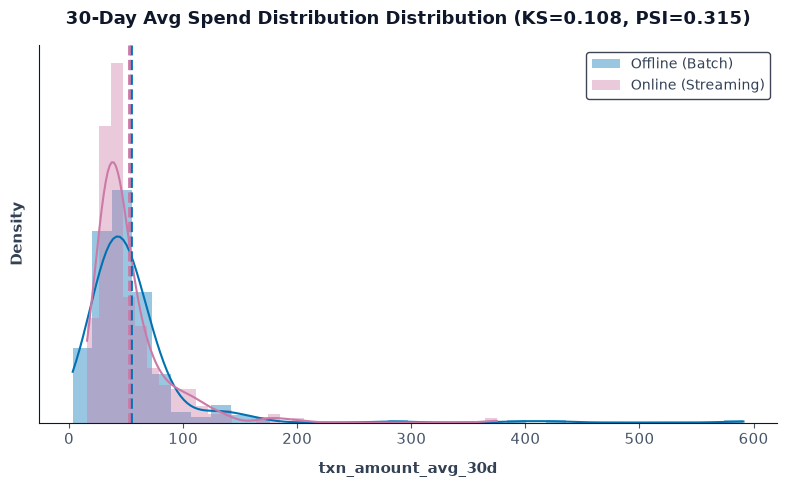

In [326]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de um único gráfico
fig, ax = plt.subplots(figsize=(8, 5))

# Plotagem: Barras do Histograma + Linha Suave do KDE (kde=True)
sns.histplot(off_v, color=COL_OFFLINE, label=f'Offline (Batch)',    kde=True, stat="density", linewidth=0, alpha=0.4, ax=ax)
sns.histplot(on_v,  color=COL_ONLINE,  label=f'Online (Streaming)', kde=True, stat="density", linewidth=0, alpha=0.4, ax=ax)

# Linhas pontilhadas marcando a média de cada distribuição
ax.axvline(off_v.mean(), color=COL_OFFLINE, linestyle='--', lw=2)
ax.axvline(on_v.mean(), color=COL_ONLINE,  linestyle='--', lw=2)

# Customização de Textos e Rótulos (Inglês para a apresentação)
ax.set_xlabel('txn_amount_avg_30d', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Density', fontsize=11, fontweight='bold', labelpad=10)

# 🎯 INSERINDO O KS E O PSI NO TÍTULO AQUI:
ax.set_title(f'30-Day Avg Spend Distribution Distribution (KS={ks_stat:.3f}, PSI={psi:.3f})', fontsize=13, fontweight='bold', pad=15)

ax.legend(fontsize=10, loc='upper right')

# Ocultando o eixo Y
ax.set_yticks([])

# Aplicando o estilo executivo e salvando
style_chart(ax)
fig.tight_layout()

plt.show()


---
# Q1.3 — Posição sobre as Mudanças Propostas

**Mudança 1**: Credit-line top-ups em tempo real, sem revisão humana → **🔴 PAUSE**  
**Mudança 2**: Processo de review mais leve para código de features → **🟡 PROSSEGUIR COM CONDIÇÕES**


---
### MUDANÇA 1: Top-ups em tempo real, sem revisão humana 🔴 PAUSE

**Risco concreto (observado hoje, não hipotético):**
- Cerca de **3%** dos clientes receberiam uma decisão diferente de crédito dependendo apenas de qual store alimenta o modelo.
- Clientes poderiam ser pontuados com features *stale* (TTL configurado mas ignorado de forma silenciosa).
- O monitoramento mostra 100% de uptime — o plantão de engenharia não tem nenhum sinal de que há problemas nos dados.

**Condições para PROSSEGUIR (após remediação completa):**
1. Enforce de `FRESHNESS_TTL` no momento da leitura em `OnlineStore.get_features()`.
2. Reconciliar a fórmula batch vs streaming (mesma matemática, mesmo nome).
3. Deploy de drift monitoring com alertas automáticos (PSI + Paridade).
4. **Definir confidence envelope:** `feature_age < 1h AND |delta_pct| < 15% AND history ≥ 30d AND dias inativo < 30d`
   > **O que é o Confidence Envelope?**
   > É a definição de um **"terreno seguro"** onde o modelo tem autonomia para tomar decisões 100% automatizadas. Se a requisição violar qualquer uma das regras abaixo, a automação é interrompida e a solicitação vai para aprovação humana:
   > - **`feature_age < 1h` (Controle de Freshness)**: Impede a aprovação usando dados velhos e estagnados. Garante que o modelo está reagindo ao comportamento recente (mitiga o Risco 2 - *Silent Staleness*).
   > - **`|delta| < 15%` (Controle de Paridade)**: Garante que o valor processado pela pipeline em tempo real é confiável e não divergiu da distribuição que o modelo espera ver (mitiga o  *Training/Serving Skew*).
   > - **`history ≥ 30d AND dias inativo < 30d` (Controle de Cold-start e Inatividade)**: Exige que o cliente possua um histórico e atividade recentes. Isso impede que novos clientes ou usuários inativos gerem Missing Values disfarçados ou métricas ruidosas na feature `txn_amount_avg_30d`.
5. Rodar *shadow-mode* por 2 semanas para validação real antes de remover o gate de revisão humana.

---
### MUDANÇA 2: Review mais leve para código de features 🟡 CONDIÇÕES

O *blast radius* (raio de impacto) é real — um commit ruim tem o poder de corromper silenciosamente todas as features. Mas um ciclo de revisão mais rápido **É** alcançável desde que protegido por *automated guards*:

- **Gate 1:** Teste de paridade automatizado deve passar no CI (delta_pct offline/online < 15%).
- **Gate 2:** Checagem de drift (PSI ou ks) em todo merge — o CI deve rejeitar se o PSI > 0.10 ou ks>5% offline vs online.
- **Gate 3:** *Shadow deployment* (execução paralela com o live) obrigatório antes do cutover.
- **Gate 4:** *Rollback playbook* documentado e ativamente testado.



# Q1.4 — Governance Foundations: Três Controles Chave

> *Independente das mudanças, quais são os dois ou três controles mais importantes?*

Três controles priorizados por redução de risco por unidade de esforço de implementação. Eles formam as três linhas de defesa técnicas contra a quebra de semântica do modelo.

**CONTROLE 1 — Confidence Envelope (Circuit Breaker no Online Store):**
* 🛡️ **Trava tripla de runtime:** Avalia a saúde da feature *antes* de injetá-la no modelo.
* ⏳ **TTL Enforcement:** Trava dura de 6 horas de idade (evita staleness silenciosa).
* 👻 **Inatividade:** Trava de 30 dias para impedir retenção indevida de clientes "fantasmas".
* 📉 **Drift Bound:** Trava matemática contra divergências absurdas de paridade.
* 🔄 **Ação:** Se a feature falhar em qualquer trava, a aprovação autônoma é abortada e ocorre o fallback para revisão humana.

**CONTROLE 2 — Feature Contracts & CI/CD Gates (Prevenção na Origem):**
* 📋 **Contratos Semânticos:** Nenhuma feature entra em produção sem declarar todos os metadados do contrato: `name`, `formula`, `type`, `owner`, `version`, `value_range` e `freshness_SLA`.
* 🔒 **Drift Gate no CI/CD:** Testes de Paridade e Distribuição (KS < 5%) rodam a cada Pull Request. Mudanças que corrompem a distribuição são bloqueadas antes do merge.
  
**CONTROLE 3 — Observabilidade Semântica (Evolução do Dashboard):**
* 👀 **Fim da "cegueira" do uptime:** O monitoramento sai da camada de infraestrutura (latência e HTTP 200) e passa a medir a semântica do dado.
* 📊 **Monitoramento Ativo:** Dashboards devem exibir o Training/Serving Skew em tempo real e alertar caso as distribuições comecem a descolar em produção.


---
# QUESTÃO 2 — Governance Framework para Data Mesh

> *Como você projetaria um framework de governance de dados e controle para feature stores e pipelines em um ambiente Data Mesh?*


## Q2.1 — O que Padronizar vs Deixar para Cada Time

A tensão central no Data Mesh: padronizar demais e você mata a autonomia dos times; padronizar de menos e você acaba com muitas definições diferentes de 'média de transação'.

**Princípio**: Padronize o **contrato de interoperabilidade** (o que o output deve garantir), não a **implementação** (como o time chega lá).


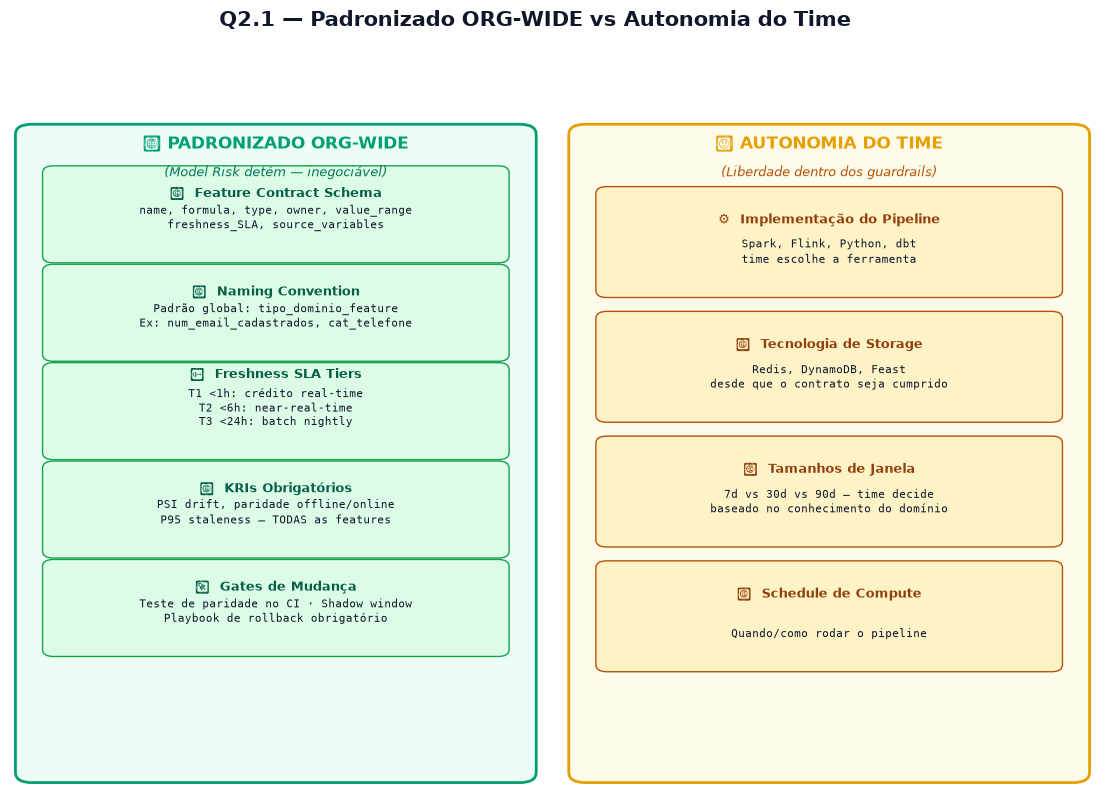

In [327]:
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle('Q2.1 — Padronizado ORG-WIDE vs Autonomia do Time', fontsize=15, color='#0f172a', fontweight='bold')
ax.set_xlim(0,10); ax.set_ylim(0,10); ax.axis('off')

# COL_LO = '#10b981' # (Você deve ter essas variáveis de cor definidas no início do seu notebook)
# COL_MED = '#f59e0b'
# OBS: Caso dê erro de cor, apenas defina as variáveis ou substitua pelas strings hex.

ax.add_patch(mpatches.FancyBboxPatch((0.2,0.3),4.5,9.2,boxstyle='round,pad=0.15',
             facecolor='#ecfdf5',edgecolor=COL_LO,linewidth=2))
ax.text(2.45,9.3,'🔒 PADRONIZADO ORG-WIDE',ha='center',fontsize=12,color=COL_LO,fontweight='bold')
ax.text(2.45,8.9,'(Model Risk detém — inegociável)',ha='center',fontsize=9,color='#047857',style='italic')

# Lado Esquerdo com 6 itens (espaçamento ajustado para caber perfeitamente)
org_wide_items = [
    ('📐  Feature Contract Schema','name, formula, type, owner, value_range\nfreshness_SLA, source_variables'),
    ('🏷  Naming Convention','Padrão global: tipo_dominio_feature\nEx: num_email_cadastrados, cat_telefone'),
    ('⏱  Freshness SLA Tiers\n','\nT1 <1h: crédito real-time\nT2 <6h: near-real-time\nT3 <24h: batch nightly'),
    ('📊  KRIs Obrigatórios','PSI drift, paridade offline/online\nP95 staleness — TODAS as features'),
    ('🚦  Gates de Mudança','Teste de paridade no CI · Shadow window\nPlaybook de rollback obrigatório'),
]

for i,(title,desc) in enumerate(org_wide_items):
    y = 8.35 - i*1.42
    ax.add_patch(mpatches.FancyBboxPatch((0.4,y-0.6),4.1,1.2,boxstyle='round,pad=0.1',facecolor='#dcfce7',edgecolor='#16a34a',linewidth=1))
    ax.text(2.45,y+0.25,title,ha='center',fontsize=9.5,color='#065f46',fontweight='bold')
    ax.text(2.45,y-0.2,desc,ha='center',fontsize=8,color='#0f172a',fontfamily='monospace',linespacing=1.3)

ax.add_patch(mpatches.FancyBboxPatch((5.3,0.3),4.5,9.2,boxstyle='round,pad=0.15',
             facecolor='#fffbeb',edgecolor=COL_MED,linewidth=2))
ax.text(7.55,9.3,'🧩 AUTONOMIA DO TIME',ha='center',fontsize=12,color=COL_MED,fontweight='bold')
ax.text(7.55,8.9,'(Liberdade dentro dos guardrails)',ha='center',fontsize=9,color='#b45309',style='italic')

# Lado Direito com 4 itens (espaçamento mais relaxado)
autonomia_items = [
    ('⚙  Implementação do Pipeline','Spark, Flink, Python, dbt\ntime escolhe a ferramenta'),
    ('🗄  Tecnologia de Storage','Redis, DynamoDB, Feast\ndesde que o contrato seja cumprido'),
    ('📐  Tamanhos de Janela','7d vs 30d vs 90d — time decide\nbaseado no conhecimento do domínio'),
    ('🔧  Schedule de Compute','Quando/como rodar o pipeline')
]

for i,(title,desc) in enumerate(autonomia_items):
    y = 7.9 - i*1.8
    ax.add_patch(mpatches.FancyBboxPatch((5.5,y-0.65),4.1,1.4,boxstyle='round,pad=0.1',facecolor='#fef3c7',edgecolor='#b45309',linewidth=1))
    ax.text(7.55,y+0.32,title,ha='center',fontsize=9.5,color='#92400e',fontweight='bold')
    ax.text(7.55,y-0.25,desc,ha='center',fontsize=8,color='#0f172a',fontfamily='monospace',linespacing=1.3)

plt.show()


## Q2.2 — Key Risk Indicators (KRIs) Scorecard (Quanti & Quali)

O framework de **Model Risk Management** avalia a saúde sistêmica dividindo os indicadores (KRIs) em duas dimensões: **Quantitativa** (dados empíricos) e **Qualitativa** (governança e controles). O peso final será 60% Quanti e 40% Quali.

### 1. Dimensão Quantitativa (KRIs Empíricas)

**KRI 1: Paridade (Training/Serving Skew)**
- **O que é:** Avalia se o cálculo da feature no motor online (streaming) produz o mesmo valor que o motor offline (batch).
- **O que mede:** A diferença percentual absoluta média (Delta) entre as duas fontes de dados.
- **Racional de Notas:** Delta < 5% = 0 pts (desvio aceitável). Entre 5-15% = 50 pts (requer investigação). > 15% = 100 pts (falha estrutural inaceitável em crédito).

**KRI 2: Estabilidade Populacional (KS Statistic)**
- **O que é:** Avalia o *Feature Drift* da população comparando a distribuição estatística de treinamento com a de inferência online.
- **O que mede:** A distância máxima entre as funções de distribuição acumulada (ECDF) usando o teste Kolmogorov-Smirnov (KS).
- **Racional de Notas:** KS < 1% = 0 pts (populações idênticas). KS < 5% = 20 pts (drift tolerável). KS < 7% = 50 pts (alerta amarelo). KS >= 7% = 100 pts (drift severo).

**KRI 3: Clientes Inativos Retidos (Silent Staleness)**
- **O que é:** Avalia se o motor online retém perfis de clientes inativos que deveriam ter sido purgados.
- **O que mede:** Número de clientes inativos retidos no online (ausentes no batch).
- **Racional de Notas:** 0 clientes = 0 pts (perfeita sincronia). > 0 clientes = 100 pts (risco sistêmico de aprovação indevida).

### 2. Dimensão Qualitativa (Controles e Governança)

**KRI 4: Feature Contract Completeness**
- **O que é:** Avalia a maturidade da documentação via código (Feature Registry).
- **O que mede:** Presença de metadados obrigatórios.
- **Racional de Notas:** ((6 - Itens implementados) / 6) * 100. Falta de itens eleva o risco.

**KRI 5: CI/CD Validation Gates**
- **O que é:** Avalia se o pipeline de deploy possui proteções automatizadas para barrar regressões silenciosas.
- **O que mede:** Presença de 4 gates de validação.
- **Racional de Notas:** ((4 - Gates implementados) / 4) * 100. Faltar gates de segurança significa maior risco em produção.

**KRI 6: Confidence Envelope**
- **O que é:** Mecanismo de defesa em tempo real (circuit breaker) no Online Store.
- **O que mede:** 3 regras ativas (TTL, |delta|, inatividade).
- **Racional de Notas:** ((3 - Regras implementadas) / 3) * 100. Sem travas, a empresa se expõe a regressões.

**KRI 7: Semantic Observability**
- **O que é:** Avalia a capacidade de observabilidade pós-deploy da Feature Store.
- **O que mede:** 3 Pilares: Latência, Disponibilidade e Drift.
- **Racional de Notas:** ((3 - Pilares monitorados) / 3) * 100. Não ter visibilidade significa alto risco operacional.


=== COMPASS MRM SCORECARD ===

[ QUANTI ] Score: 0.0/100
  - Paridade (Peso 40.0%): 0 pts
  - KS Drift (Peso 30.0%): 0 pts
  - Staleness (Peso 30.0%): 0 pts

[ QUALI ] Score: 33.3/100
  - Feature Contract (Peso 25.0%): 66.7 pts
  - CI/CD Gates (Peso 25.0%): 0.0 pts
  - Confidence Env (Peso 25.0%): 0.0 pts
  - Monitoramento (Peso 25.0%): 66.7 pts

>>> SCORE FINAL DE RISCO: 13.3/100 <<<



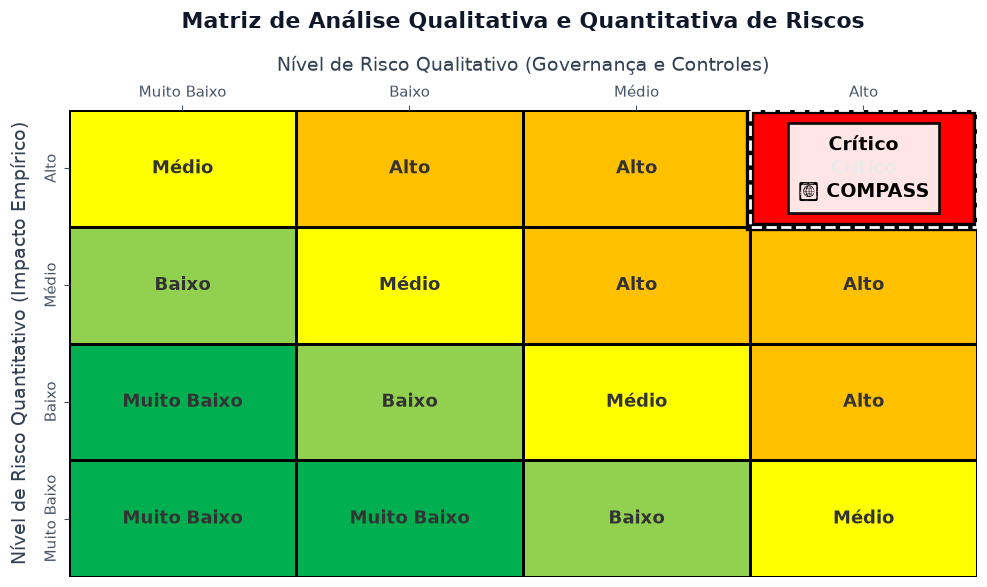

In [331]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 0. CONFIGURAÇÃO DE PESOS
# ==========================================
pesos = {
    'quanti': {
        'KRI1_Paridade': 0.4,
        'KRI2_Drift_KS': 0.3,
        'KRI3_Staleness': 0.3
    },
    'quali': {
        'KRI4_Feature_Contract': 0.25,
        'KRI5_CI_Gates': 0.25,
        'KRI6_Confidence_Envelope': 0.25,
        'KRI7_Monitoramento': 0.25
    },
    'dimensao': {
        'quanti': 0.60,
        'quali': 0.40
    }
}

# ==========================================
# 1. DIMENSÃO QUANTITATIVA
# ==========================================
delta_medio = df_merged['abs_delta'].mean()
nota_kri1 = 0 if delta_medio < 5 else (50 if delta_medio <= 15 else 100)
if ks_percent < 1:
    nota_kri2 = 0
elif ks_percent < 5:
    nota_kri2 = 20
elif ks_percent < 7:
    nota_kri2 = 50
else:
    nota_kri2 = 100
nota_kri3 = 0 if n_inactive_lost == 0 else 100

score_quanti = (nota_kri1 * pesos['quanti']['KRI1_Paridade']) + \
               (nota_kri2 * pesos['quanti']['KRI2_Drift_KS']) + \
               (nota_kri3 * pesos['quanti']['KRI3_Staleness'])

# ==========================================
# 2. DIMENSÃO QUALITATIVA (Simulação Estado Atual)
# ==========================================
# KRI 4: Atual (antes da remediação): Faltam value_range e freshness_SLA no contrato
kri4_itens = 4 # de 6
nota_kri4 = ((6 - kri4_itens) / 6) * 100

# KRI 5: Atual: Nenhum gate de validação no CI
kri5_gates = 0 # de 4
nota_kri5 = ((4 - kri5_gates) / 4) * 100

# KRI 6: Atual: Nenhum envelope de confiança ativo
kri6_regras = 0 # de 3
nota_kri6 = ((3 - kri6_regras) / 3) * 100

# KRI 7: Atual: Só tem latência e estabilidade, falta drift online/offline
kri7_monitores = 2 # de 3
nota_kri7 = ((3 - kri7_monitores) / 3) * 100

score_quali = (nota_kri4 * pesos['quali']['KRI4_Feature_Contract']) + \
              (nota_kri5 * pesos['quali']['KRI5_CI_Gates']) + \
              (nota_kri6 * pesos['quali']['KRI6_Confidence_Envelope']) + \
              (nota_kri7 * pesos['quali']['KRI7_Monitoramento'])

# ==========================================
# 3. SCORE FINAL
# ==========================================
score_final = (score_quanti * pesos['dimensao']['quanti']) + (score_quali * pesos['dimensao']['quali'])

print("=== COMPASS MRM SCORECARD ===\n")
print(f"[ QUANTI ] Score: {score_quanti:.1f}/100")
print(f"  - Paridade (Peso {pesos['quanti']['KRI1_Paridade']*100}%): {nota_kri1} pts")
print(f"  - KS Drift (Peso {pesos['quanti']['KRI2_Drift_KS']*100}%): {nota_kri2} pts")
print(f"  - Staleness (Peso {pesos['quanti']['KRI3_Staleness']*100}%): {nota_kri3} pts\n")
print(f"[ QUALI ] Score: {score_quali:.1f}/100")
print(f"  - Feature Contract (Peso {pesos['quali']['KRI4_Feature_Contract']*100}%): {nota_kri4:.1f} pts")
print(f"  - CI/CD Gates (Peso {pesos['quali']['KRI5_CI_Gates']*100}%): {nota_kri5:.1f} pts")
print(f"  - Confidence Env (Peso {pesos['quali']['KRI6_Confidence_Envelope']*100}%): {nota_kri6:.1f} pts")
print(f"  - Monitoramento (Peso {pesos['quali']['KRI7_Monitoramento']*100}%): {nota_kri7:.1f} pts\n")
print(f">>> SCORE FINAL DE RISCO: {score_final:.1f}/100 <<<\n")

# ==========================================
# 4. PLOT: MATRIZ DE RISCO (ESTILO PMBOK)
# ==========================================
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def get_risco_label(score):
    if score >= 60: return 'Alto'
    elif score >= 40: return 'Médio'
    elif score >= 20: return 'Baixo'
    else: return 'Muito Baixo'
lbl_quanti = get_risco_label(score_quanti)
lbl_quali = get_risco_label(score_quali)

cat_y = ['Alto', 'Médio', 'Baixo', 'Muito Baixo']
cat_x = ['Muito Baixo', 'Baixo', 'Médio', 'Alto']

matriz_num = np.array([
    [2, 3, 3, 4], # Alto
    [1, 2, 3, 3], # Médio
    [0, 1, 2, 3], # Baixo
    [0, 0, 1, 2]  # Muito Baixo
])

matriz_text = np.array([
    ['Médio', 'Alto', 'Alto', 'Crítico'],
    ['Baixo', 'Médio', 'Alto', 'Alto'],
    ['Muito Baixo', 'Baixo', 'Médio', 'Alto'],
    ['Muito Baixo', 'Muito Baixo', 'Baixo', 'Médio']
], dtype=object)

idx_y = cat_y.index(lbl_quanti)
idx_x = cat_x.index(lbl_quali)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = sns.color_palette(['#00b050', '#92d050', '#ffff00', '#ffc000', '#ff0000'])

sns.heatmap(matriz_num, annot=matriz_text, fmt='', cmap=cmap, cbar=False, 
            xticklabels=cat_x, yticklabels=cat_y, 
            linewidths=2, linecolor='black', ax=ax, annot_kws={"size": 13, "weight": "bold", "color": "#333333"})

# Destacando dramaticamente a célula atual do Compass
# 1. Borda dupla grossa (Preto + Branco Tracejado) em volta da célula
ax.add_patch(patches.Rectangle((idx_x, idx_y), 1, 1, fill=False, edgecolor='black', lw=6, zorder=10))
ax.add_patch(patches.Rectangle((idx_x, idx_y), 1, 1, fill=False, edgecolor='white', lw=2, linestyle='--', zorder=11))

# 2. Bloco flutuante com sombra cobrindo o texto original para chamar a atenção
texto_base = matriz_text[idx_y, idx_x]
ax.text(idx_x + 0.5, idx_y + 0.5, f"{texto_base}\n\n🎯 COMPASS", 
        ha='center', va='center', color='black', fontweight='900', fontsize=14, zorder=12,
        bbox=dict(facecolor='white', alpha=0.9, edgecolor='black', boxstyle='square,pad=0.5', lw=2))

ax.set_title('Matriz de Análise Qualitativa e Quantitativa de Riscos', fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel('Nível de Risco Qualitativo (Governança e Controles)', fontsize=14, labelpad=10)
ax.set_ylabel('Nível de Risco Quantitativo (Impacto Empírico)', fontsize=14, labelpad=10)

ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


## Q2.3 — Governance Sem Virar Gargalo

A solução é **governance baseada em risco** — pipelines de alto risco recebem mais escrutínio, pipelines de baixo risco têm aprovação rápida. O custo de compliance é proporcional ao risco, não uniforme.

## Q2.4 — Driving Adoption Sem Autoridade Direta

O maior desafio de governance em Data Mesh: você não pode mandar — você precisa tornar o compliance o caminho de menor resistência.


In [329]:
# Risk tiering
pe = pd.DataFrame([
    {'pipeline':'Compass (top-ups real-time)', 'credit':1,'automated':1,'realtime':1,'human':0},
    {'pipeline':'Compass (underwriting batch)', 'credit':1,'automated':0,'realtime':0,'human':1},
    {'pipeline':'Fraud detection features',     'credit':0,'automated':1,'realtime':1,'human':0},
    {'pipeline':'Marketing feature store',      'credit':0,'automated':1,'realtime':0,'human':0},
    {'pipeline':'Customer segmentation',        'credit':0,'automated':0,'realtime':0,'human':1},
    {'pipeline':'Churn prediction',             'credit':0,'automated':0,'realtime':0,'human':1},
])
pe['risk_score'] = pe['credit']*40 + pe['automated']*30 + pe['realtime']*20 + (1-pe['human'])*10
pe['tier'] = pe['risk_score'].apply(lambda x:
    'T1 — Alto (revisão completa 5-7d)' if x>=70 else
    ('T2 — Médio (auto+amostra 1-2d)' if x>=40 else 'T3 — Baixo (CI <1h)'))

display(pe[['pipeline','risk_score','tier']].sort_values('risk_score',ascending=False))
print()
print(f'2 de {len(pe)} pipelines exigem revisão completa (T1).')
print(f'{(pe["risk_score"]<70).sum()} pipelines podem shipar com gates automatizados em <2 dias.')
print('Governance não é imposto uniforme — é proporcional ao risco.')


,pipeline,risk_score,tier
0,Compass (top-ups real-time),100,T1 — Alto (revisão completa 5-7d)
2,Fraud detection features,60,T2 — Médio (auto+amostra 1-2d)
1,Compass (underwriting batch),40,T2 — Médio (auto+amostra 1-2d)
3,Marketing feature store,40,T2 — Médio (auto+amostra 1-2d)
4,Customer segmentation,0,T3 — Baixo (CI <1h)
5,Churn prediction,0,T3 — Baixo (CI <1h)



2 de 6 pipelines exigem revisão completa (T1).
5 pipelines podem shipar com gates automatizados em <2 dias.
Governance não é imposto uniforme — é proporcional ao risco.
